# MLflow Evaluation Run Comparison

Compare RAGAS scores across multiple MLflow runs side-by-side.

**Input:** `RUNS` list of `(run_id, label)` pairs.  
**Output:** Tables and charts aggregated by overall, `question_class`, `subdomain`, and `(question_class, subdomain)`.

In [30]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import mlflow
import numpy as np
import pandas as pd
from mlflow.tracking import MlflowClient

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)

In [31]:
# ── Configuration ─────────────────────────────────────────────────────────────
MLFLOW_TRACKING_URI = "http://localhost:8567"

# Each entry: (run_id, human_readable_label)
RUNS = [
    ("f6d783f661a644a58865384534021c32", "baseline/semantic/4o-mini"),
    ("144d504d4b1b454f8505f54697c69250", "baseline/bm25/4o-mini"),
    ("2ebab2b7d6ad46859eab992a06c5ccad", "baseline/hybrid/4o-mini"),
    ("412a730db5e04a4da436218d6321d1cd", "query_rewriting, hybrid, 4o-mini"),
    ("9df381d8997646e797d34917dd394dee", "rag_agent/hybrid/4o-mini")
]

RAGAS_TABLE_ARTIFACT = "ragas_scores.json"

METRIC_COLS = [
    "faithfulness",
    "context_precision",
    "context_recall",
    "answer_relevance",
    "factual_correctness",
    "factual_correctness_recall",
]

# Short metric names for chart axis labels.
METRIC_SHORT = {
    "faithfulness": "Faith.",
    "context_precision": "Ctx Prec.",
    "context_recall": "Ctx Rec.",
    "answer_relevance": "Ans Rel.",
    "factual_correctness": "FC",
    "factual_correctness_recall": "FC Rec.",
}

# Question classes excluded from subdomain and overall aggregations.
# "unanswerable" questions score 0 on retrieval/relevance metrics by design,
# so including them in averages would unfairly dilute results.
EXCLUDE_QUESTION_CLASSES = ["unanswerable"]

# ── Derived convenience maps (do not edit) ────────────────────────────────────
RUN_IDS    = [r for r, _ in RUNS]
RUN_LABELS = {r: lbl for r, lbl in RUNS}

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = MlflowClient()
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Runs configured: {len(RUNS)}")
for rid, lbl in RUNS:
    print(f"  {rid[:8]}…  →  {lbl}")

Tracking URI: http://localhost:8567
Runs configured: 5
  f6d783f6…  →  baseline/semantic/4o-mini
  144d504d…  →  baseline/bm25/4o-mini
  2ebab2b7…  →  baseline/hybrid/4o-mini
  412a730d…  →  query_rewriting, hybrid, 4o-mini
  9df381d8…  →  rag_agent/hybrid/4o-mini


In [32]:
# ── Helpers ───────────────────────────────────────────────────────────────────
def list_artifacts_recursive(run_id: str, path: str = ""):
    items = []
    for art in client.list_artifacts(run_id, path):
        items.append(art.path)
        if art.is_dir:
            items.extend(list_artifacts_recursive(run_id, art.path))
    return items


def normalize_logged_table(json_obj) -> pd.DataFrame:
    if isinstance(json_obj, list):
        return pd.DataFrame(json_obj)
    if isinstance(json_obj, dict):
        if "data" in json_obj and "columns" in json_obj:
            return pd.DataFrame(json_obj["data"], columns=json_obj["columns"])
        return pd.DataFrame(json_obj)
    raise ValueError("Unsupported ragas_scores.json structure")


def load_ragas_table(run_id: str) -> pd.DataFrame | None:
    artifact_paths = list_artifacts_recursive(run_id)
    matches = [p for p in artifact_paths if p.endswith(RAGAS_TABLE_ARTIFACT)]
    if not matches:
        return None
    local_path = client.download_artifacts(run_id, matches[0])
    with open(local_path, "r", encoding="utf-8") as f:
        payload = json.load(f)
    df = normalize_logged_table(payload)
    for col in METRIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def run_label(run_id: str) -> str:
    return RUN_LABELS.get(run_id, run_id[:8])

In [33]:
# ── Load data for each run ────────────────────────────────────────────────────
run_data: dict[str, pd.DataFrame] = {}
failed: list[str] = []

for run_id, label in RUNS:
    df = load_ragas_table(run_id)
    if df is None:
        print(f"  [MISS]  {run_id}  ({label}) — no {RAGAS_TABLE_ARTIFACT} found")
        failed.append(run_id)
    else:
        df["run_id"]    = run_id
        df["run_label"] = label
        run_data[run_id] = df
        print(f"  [OK]    {run_id}  ({label})  — {len(df)} rows")

if not run_data:
    raise ValueError("No ragas_scores.json found for any of the supplied run IDs.")

print(f"\nLoaded {len(run_data)}/{len(RUNS)} runs successfully.")
if failed:
    print(f"Missing: {failed}")

# Ordered label list — used to keep run order consistent across all tables/charts.
LABELS = [run_label(r) for r in RUN_IDS if r in run_data]

  [OK]    f6d783f661a644a58865384534021c32  (baseline/semantic/4o-mini)  — 20 rows


  [OK]    144d504d4b1b454f8505f54697c69250  (baseline/bm25/4o-mini)  — 20 rows


  [OK]    2ebab2b7d6ad46859eab992a06c5ccad  (baseline/hybrid/4o-mini)  — 20 rows


  [OK]    412a730db5e04a4da436218d6321d1cd  (query_rewriting, hybrid, 4o-mini)  — 20 rows


  [OK]    9df381d8997646e797d34917dd394dee  (rag_agent/hybrid/4o-mini)  — 20 rows

Loaded 5/5 runs successfully.


In [34]:
# ── Aggregation helpers ───────────────────────────────────────────────────────
def build_comparison(group_col, exclude_classes=None) -> pd.DataFrame:
    """
    group_col      : str | list[str] | None — column(s) to group by.
                     None → single overall mean row per run.
    exclude_classes: list[str] | None — question_class values to drop first.

    Returns:
      group_col=None  → DataFrame  rows=runs, cols=metrics
      otherwise       → DataFrame  MultiIndex cols (metric, run), rows=group values
    """
    frames = {}
    for run_id, df in run_data.items():
        label = run_label(run_id)
        sub = df.copy()
        if exclude_classes:
            sub = sub[~sub["question_class"].isin(exclude_classes)]
        metrics_present = [c for c in METRIC_COLS if c in sub.columns]
        if group_col is None:
            frames[label] = sub[metrics_present].mean(numeric_only=True).rename(label)
        else:
            agg = sub.groupby(group_col, dropna=False)[metrics_present].mean(numeric_only=True)
            agg.columns = pd.MultiIndex.from_tuples([(c, label) for c in agg.columns])
            frames[label] = agg

    if group_col is None:
        return pd.DataFrame(frames).T.loc[LABELS]  # preserve run order

    combined = pd.concat(frames.values(), axis=1)
    combined.columns.names = ["metric", "run"]
    metrics_in = [c for c in METRIC_COLS if c in combined.columns.get_level_values(0)]
    combined = combined.reindex(
        columns=pd.MultiIndex.from_product([metrics_in, LABELS], names=["metric", "run"])
    )
    return combined


def metrics_present_in(df: pd.DataFrame) -> list[str]:
    if isinstance(df.columns, pd.MultiIndex):
        return [c for c in METRIC_COLS if c in df.columns.get_level_values(0)]
    return [c for c in METRIC_COLS if c in df.columns]

In [35]:
# ── Chart helpers ─────────────────────────────────────────────────────────────
COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]


def grouped_bar(ax, df_rows_runs: pd.DataFrame, title: str, ylabel="Score"):
    """
    df_rows_runs: rows = group values (or single row for overall),
                  cols = run labels, values = metric score.
    Draws a grouped bar chart on `ax`.
    """
    groups   = list(df_rows_runs.index)
    runs     = list(df_rows_runs.columns)
    n_groups = len(groups)
    n_runs   = len(runs)
    width    = 0.8 / n_runs
    x        = np.arange(n_groups)

    for i, run in enumerate(runs):
        offset = (i - (n_runs - 1) / 2) * width
        vals   = df_rows_runs[run].values.astype(float)
        bars   = ax.bar(x + offset, vals, width * 0.9, label=run, color=COLORS[i % len(COLORS)])
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f"{v:.2f}",
                    ha="center", va="bottom", fontsize=6, rotation=90,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [str(g) for g in groups], rotation=30, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.18)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(axis="y", linestyle="--", alpha=0.4)


def plot_overall_bars(overall: pd.DataFrame):
    """One grouped bar per metric, bars = runs."""
    metrics = metrics_present_in(overall)
    short   = [METRIC_SHORT.get(m, m) for m in metrics]
    fig, ax = plt.subplots(figsize=(max(8, len(metrics) * 1.5), 4.5))
    plot_df = overall[metrics].T.copy()
    plot_df.index = short
    grouped_bar(ax, plot_df, title="Overall mean scores by metric (excluding: " + str(EXCLUDE_QUESTION_CLASSES) + ")")
    ax.set_xlabel("Metric", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_by_group(comp: pd.DataFrame, group_name: str):
    """One subplot per metric, grouped bars over group values."""
    metrics = metrics_present_in(comp)
    n = len(metrics)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.5, nrows * 4.5))
    axes_flat = np.array(axes).flatten()

    for i, metric in enumerate(metrics):
        ax     = axes_flat[i]
        subset = comp[metric].copy()  # rows=group, cols=runs
        # Shorten long index labels
        subset.index = [
            str(idx)[:35] + "…" if len(str(idx)) > 35 else str(idx)
            for idx in subset.index
        ]
        grouped_bar(ax, subset, title=metric)
        ax.set_xlabel(group_name, fontsize=8)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.suptitle(f"Scores by {group_name}", fontsize=11, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_radar(overall: pd.DataFrame):
    """Radar / spider chart — one polygon per run."""
    metrics = metrics_present_in(overall)
    short   = [METRIC_SHORT.get(m, m) for m in metrics]
    N       = len(metrics)
    angles  = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
    for i, label in enumerate(LABELS):
        vals  = overall.loc[label, metrics].values.astype(float).tolist()
        vals += vals[:1]
        color = COLORS[i % len(COLORS)]
        ax.plot(angles, vals, color=color, linewidth=1.5, label=label)
        ax.fill(angles, vals, color=color, alpha=0.10)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(short, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=6)
    ax.set_title("Overall scores — radar", fontsize=10, fontweight="bold", pad=12)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=7)
    plt.tight_layout()
    plt.show()


def plot_heatmap(overall: pd.DataFrame, title=""):
    """Heatmap: rows=runs, cols=metrics."""
    metrics = metrics_present_in(overall)
    data    = overall[metrics].astype(float)
    data.columns = [METRIC_SHORT.get(c, c) for c in data.columns]

    fig, ax = plt.subplots(figsize=(max(6, len(metrics) * 1.2), max(2, len(LABELS) * 0.6 + 1)))
    im = ax.imshow(data.values, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, fontsize=9)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index, fontsize=8)

    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            v = data.iloc[r, c]
            ax.text(c, r, f"{v:.3f}", ha="center", va="center", fontsize=8,
                    color="black" if 0.3 < v < 0.8 else "white")

    ax.set_title(title or "Score heatmap", fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()

---
## 1. Overall mean (excluding specified question classes)

In [36]:
print(f"Excluding question classes: {EXCLUDE_QUESTION_CLASSES or 'none'}")
overall = build_comparison(group_col=None, exclude_classes=EXCLUDE_QUESTION_CLASSES)
display(overall)

Excluding question classes: ['unanswerable']


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
baseline/semantic/4o-mini,0.7185,0.6515,0.5556,0.7929,0.5007,0.6093
baseline/bm25/4o-mini,0.7973,0.7000,0.5778,0.8236,0.4853,0.6320
baseline/hybrid/4o-mini,0.8058,0.7521,0.6111,0.8889,0.4740,0.5827
"query_rewriting, hybrid, 4o-mini",0.8045,0.7146,0.6222,0.8642,0.5247,0.6560
rag_agent/hybrid/4o-mini,0.7156,0.7113,0.6190,0.9044,0.4660,0.7053


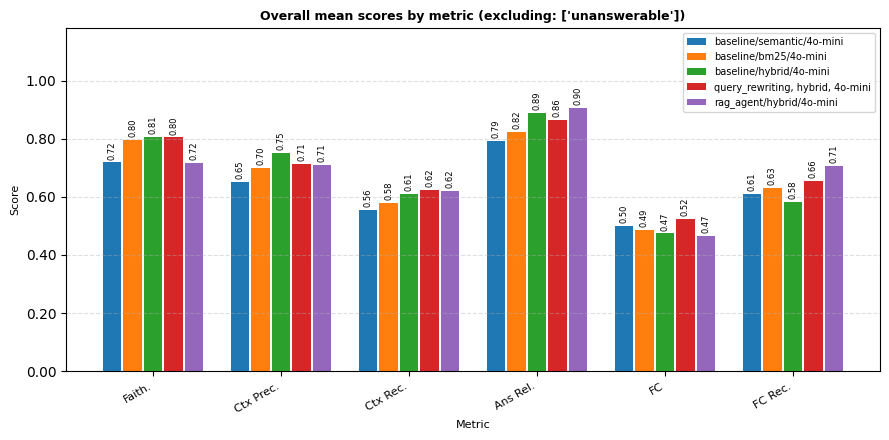

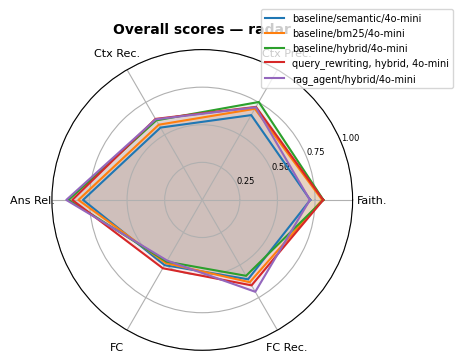

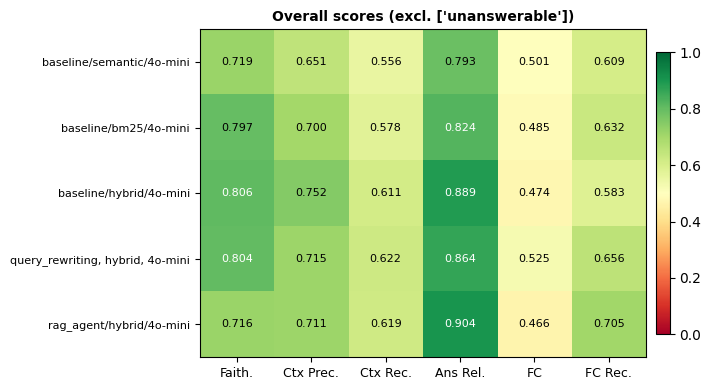

In [37]:
plot_overall_bars(overall)
plot_radar(overall)
plot_heatmap(overall, title=f"Overall scores (excl. {EXCLUDE_QUESTION_CLASSES})")

---
## 2. By `question_class`

All question classes included so you can also inspect unanswerable scores.

In [38]:
by_qclass = build_comparison(group_col="question_class", exclude_classes=None)
display(by_qclass)

metric                      faithfulness                                                                                                                 context_precision                        \
run            baseline/semantic/4o-mini baseline/bm25/4o-mini baseline/hybrid/4o-mini query_rewriting, hybrid, 4o-mini rag_agent/hybrid/4o-mini baseline/semantic/4o-mini baseline/bm25/4o-mini   
question_class                                                                                                                                                                                     
fact_single                       0.8700                0.8000                  0.8000                           0.9333                   0.9000                    0.7706                0.6306   
reasoning                         0.7925                0.6971                  0.8143                           0.7254                   0.6151                    0.6561                0.6933   
summary                           0.4930                0.8947                  0.8049                           0.7548                   0.6116                    0.5278                0.7761   
unanswerable                      0.6571                0.6000                  0.8000                           0.5500                   0.3103                    0.0000                0.0667   

metric                                                                                                      context_recall                                                \
run            baseline/hybrid/4o-mini query_rewriting, hybrid, 4o-mini rag_agent/hybrid/4o-mini baseline/semantic/4o-mini baseline/bm25/4o-mini baseline/hybrid/4o-mini   
question_class                                                                                                                                                             
fact_single                     0.7971                           0.7989                   0.7387                    0.8000                0.8000                  0.8000   
reasoning                       0.7625                           0.7342                   0.7847                    0.5000                0.5000                  0.6000   
summary                         0.6968                           0.6108                   0.6252                    0.3667                0.4333                  0.4333   
unanswerable                    0.0000                           0.0000                   0.0000                    0.0000                0.2000                  0.0000   

metric                                                                            answer_relevance                                                                                 \
run            query_rewriting, hybrid, 4o-mini rag_agent/hybrid/4o-mini baseline/semantic/4o-mini baseline/bm25/4o-mini baseline/hybrid/4o-mini query_rewriting, hybrid, 4o-mini   
question_class                                                                                                                                                                      
fact_single                              0.8000                   1.0000                    0.8964                0.7226                  0.7760                           0.7739   
reasoning                                0.6000                   0.5000                    0.9318                0.9079                  0.9545                           0.9344   
summary                                  0.4667                   0.3333                    0.5504                0.8404                  0.9362                           0.8845   
unanswerable                             0.0000                   0.2000                    0.0000                0.1821                  0.0000                           0.0000   

metric                                        factual_correctness                                                                                         

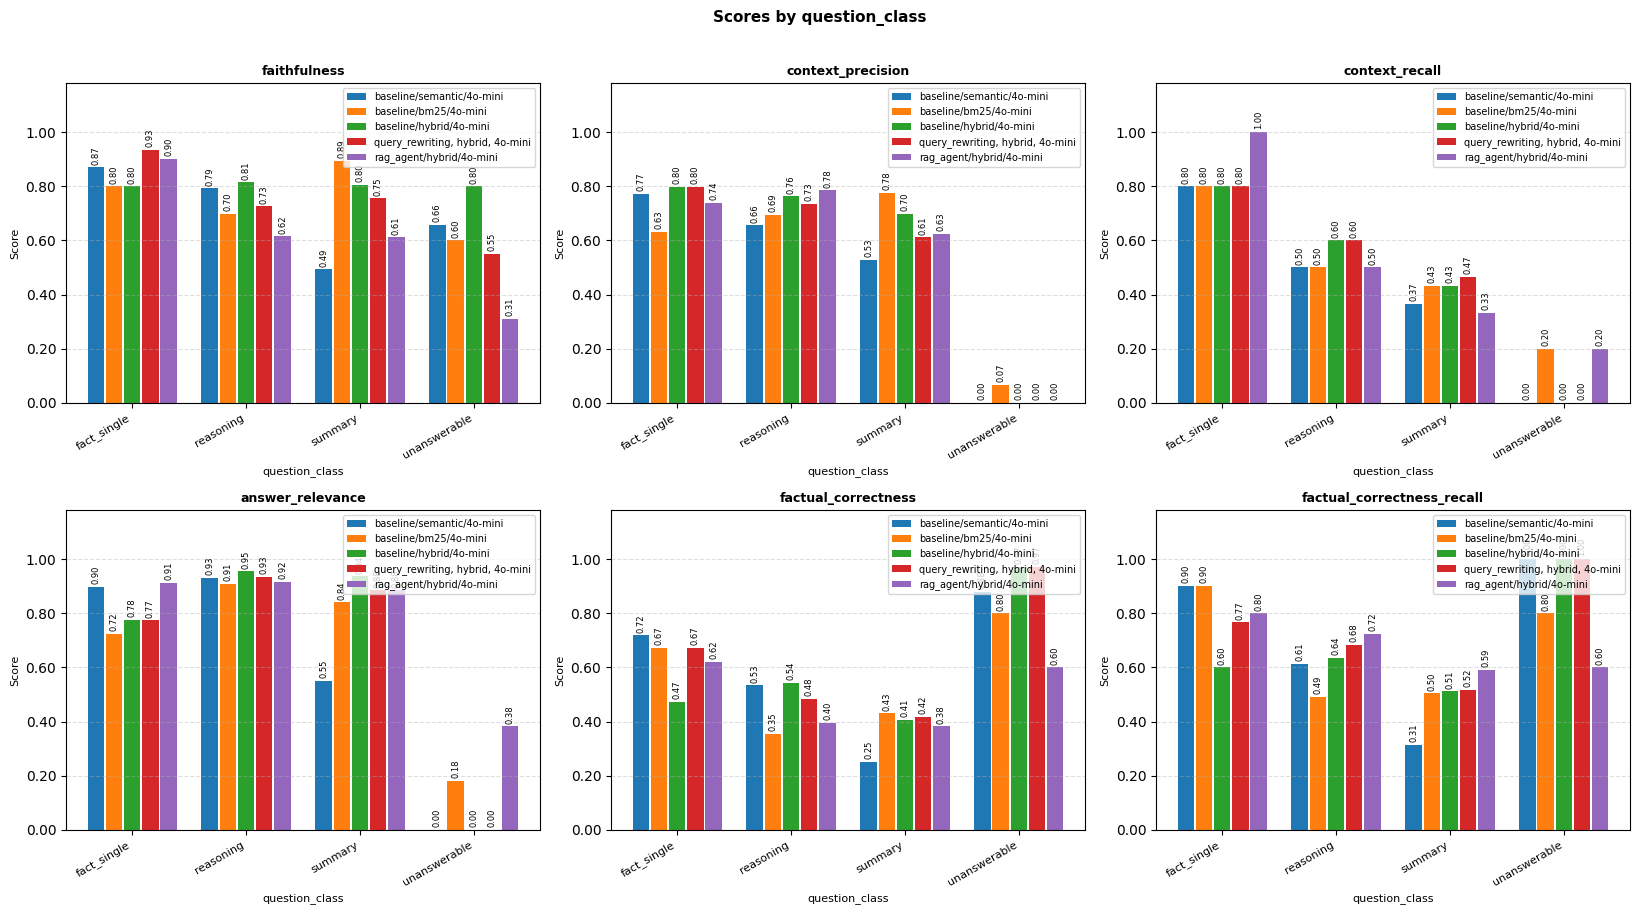

In [39]:
plot_by_group(by_qclass, group_name="question_class")

---
## 3. By `subdomain` (excluding specified question classes)

In [40]:
print(f"Excluding question classes: {EXCLUDE_QUESTION_CLASSES or 'none'}")
by_subdomain = build_comparison(group_col="subdomain", exclude_classes=EXCLUDE_QUESTION_CLASSES)
display(by_subdomain)

Excluding question classes: ['unanswerable']


metric                                                          faithfulness                                                                                                          \
run                                                baseline/semantic/4o-mini baseline/bm25/4o-mini baseline/hybrid/4o-mini query_rewriting, hybrid, 4o-mini rag_agent/hybrid/4o-mini   
subdomain                                                                                                                                                                              
experiment_tracking_fundamentals                                      0.8542                0.6786                  0.8500                           0.9259                   0.5986   
mlflow_tracking_api                                                   0.8061                0.4667                  0.4000                           0.6204                   0.5350   
nisq_constraints_and_qsd_constraints                                  0.8157                0.8745                  0.8718                           0.7381                   0.7384   
qiskit-specific_experiment_tracking_using_mlflo...                    0.5167                0.9667                  1.0000                           0.9524                   0.9524   
qprov_provenance_taxonomy                                             0.6000                1.0000                  0.9221                           0.7857                   0.7727   

metric                                                     context_precision                                                                                                          \
run                                                baseline/semantic/4o-mini baseline/bm25/4o-mini baseline/hybrid/4o-mini query_rewriting, hybrid, 4o-mini rag_agent/hybrid/4o-mini   
subdomain                                                                                                                                                                              
experiment_tracking_fundamentals                                      0.8167                0.5700                  0.8023                           0.8444                   0.8685   
mlflow_tracking_api                                                   0.7778                0.2639                  0.6075                           0.4722                   0.4052   
nisq_constraints_and_qsd_constraints                                  0.7593                0.8407                  0.8722                           0.7551                   0.8148   
qiskit-specific_experiment_tracking_using_mlflo...                    0.5366                0.9185                  0.6732                           0.6681                   0.6290   
qprov_provenance_taxonomy                                             0.3672                0.9069                  0.8056                           0.8333                   0.9028   

metric                                                        context_recall                                                                                                          \
run                                                baseline/semantic/4o-mini baseline/bm25/4o-mini baseline/hybrid/4o-mini query_rewriting, hybrid, 4o-mini rag_agent/hybrid/4o-mini   
subdomain                                                                                                                                                                              
experiment_tracking_fundamentals                                      0.7222                0.4444                  0.7222                           0.7222                   0.4444   
mlflow_tracking_api                                                   0.1667                0.3333                  0.1667                           0.1667                   0.3333   
nisq_constraints_and_qsd_constraints                                  0.8889                0.7778                  0.6667            

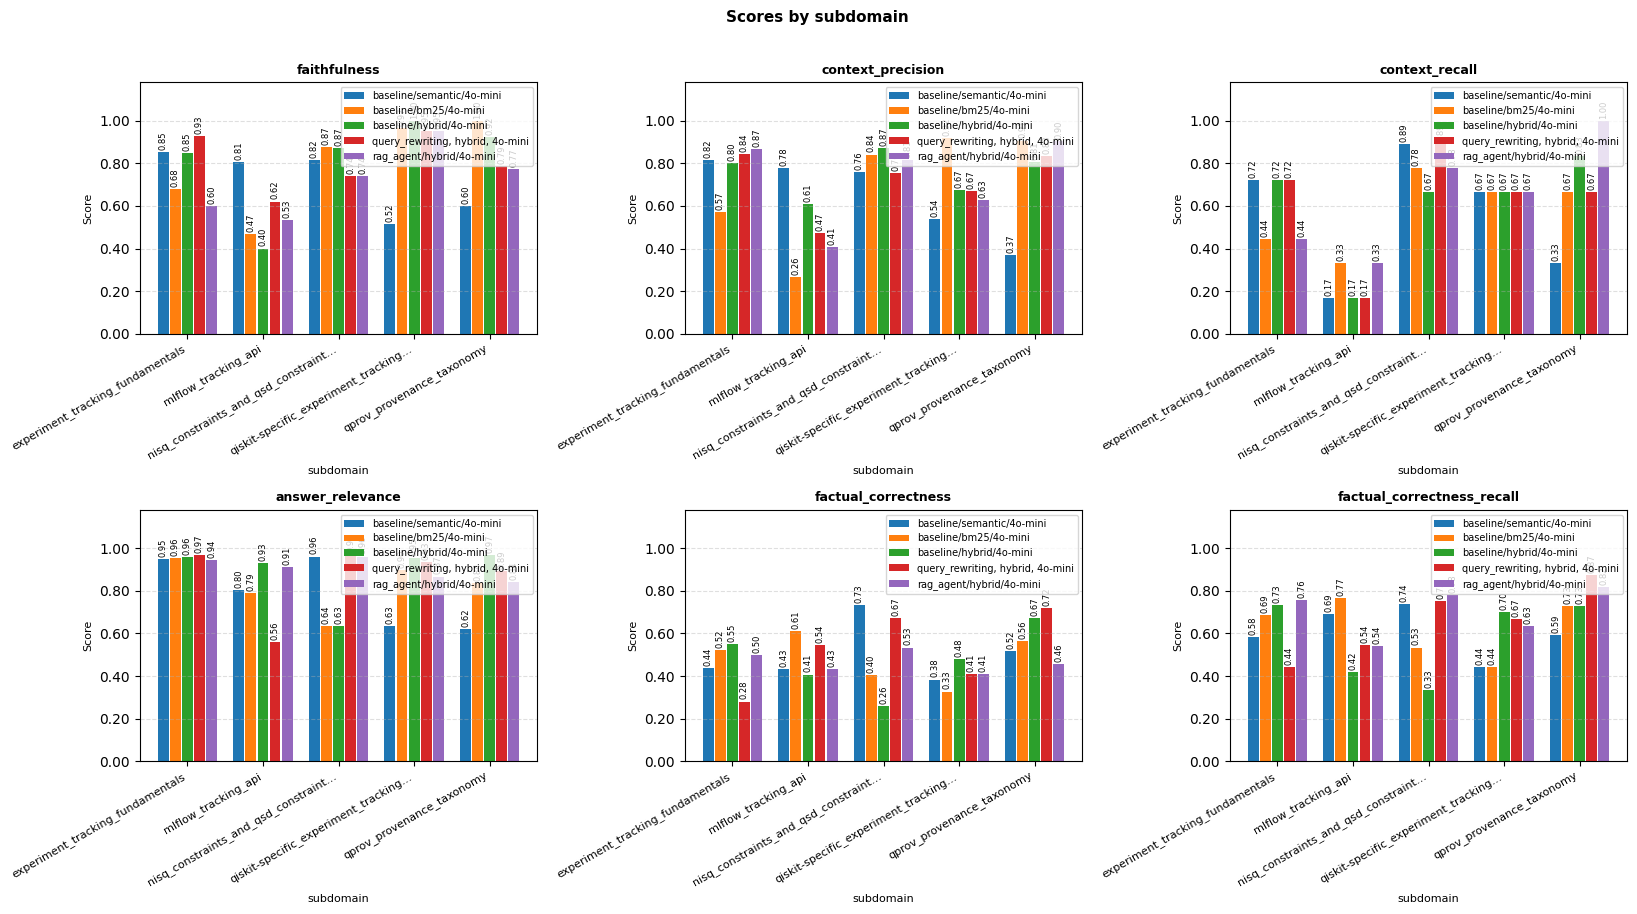

In [41]:
plot_by_group(by_subdomain, group_name="subdomain")

---
## 4. By `(question_class, subdomain)`

In [42]:
by_qclass_subdomain = build_comparison(
    group_col=["question_class", "subdomain"], exclude_classes=None
)
display(by_qclass_subdomain)

metric                                                                         faithfulness                                                                                                          \
run                                                               baseline/semantic/4o-mini baseline/bm25/4o-mini baseline/hybrid/4o-mini query_rewriting, hybrid, 4o-mini rag_agent/hybrid/4o-mini   
question_class subdomain                                                                                                                                                                              
fact_single    experiment_tracking_fundamentals                                      1.0000                1.0000                  1.0000                           1.0000                   1.0000   
               mlflow_tracking_api                                                   0.6000                0.0000                  0.0000                           0.6667                   0.5000   
               nisq_constraints_and_qsd_constraints                                  1.0000                1.0000                  1.0000                           1.0000                   1.0000   
               qiskit-specific_experiment_tracking_using_mlflo...                    0.7500                1.0000                  1.0000                           1.0000                   1.0000   
               qprov_provenance_taxonomy                                             1.0000                1.0000                  1.0000                           1.0000                   1.0000   
reasoning      experiment_tracking_fundamentals                                      0.5625                0.2857                     NaN                           0.7778                   0.1000   
               mlflow_tracking_api                                                   1.0000                0.4000                  0.4000                           0.7778                   0.9231   
               nisq_constraints_and_qsd_constraints                                  0.8000                0.8000                  1.0000                           0.7143                   0.4375   
               qiskit-specific_experiment_tracking_using_mlflo...                    0.8000                1.0000                  1.0000                           1.0000                   1.0000   
               qprov_provenance_taxonomy                                             0.8000                1.0000                  0.8571                           0.3571                      NaN   
summary        experiment_tracking_fundamentals                                      1.0000                0.7500                  0.7000                           1.0000                   0.6957   
               mlflow_tracking_api                                                   0.8182                1.0000                  0.8000                           0.4167                   0.1818   
               nisq_constraints_and_qsd_constraints                                  0.6471                0.8235                  0.6154                           0.5000                   0.7778   
               qiskit-specific_experiment_tracking_using_mlflo...                    0.0000                0.9000                  1.0000                           0.8571                   0.8571   
               qprov_provenance_taxonomy                                             0.0000                1.0000                  0.9091                           1.0000                   0.5455   
unanswerable   experiment_tracking_fundamentals                                      1.0000                1.0000                  1.0000                           1.0000                   0.0000   
               mlflow_tracking_api                                                   0.2857                0.0000                  0.0000                           0.0000                   0.1765   
               nisq_

---
## 5. Delta vs. first run

Positive = improvement over the first run in `RUNS`.

In [43]:
if len(run_data) < 2:
    print("Need at least 2 runs to compute deltas.")
else:
    baseline_label = LABELS[0]
    print(f"Delta = run − '{baseline_label}'  (positive = improvement)")
    delta = overall.copy().subtract(overall.loc[baseline_label])
    delta_others = delta.drop(index=baseline_label)
    display(delta_others)

Delta = run − 'baseline/semantic/4o-mini'  (positive = improvement)


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
baseline/bm25/4o-mini,0.0788,0.0485,0.0222,0.0307,-0.0153,0.0227
baseline/hybrid/4o-mini,0.0873,0.1006,0.0556,0.0960,-0.0267,-0.0267
"query_rewriting, hybrid, 4o-mini",0.0860,0.0631,0.0667,0.0713,0.0240,0.0467
rag_agent/hybrid/4o-mini,-0.0029,0.0598,0.0635,0.1115,-0.0347,0.0960


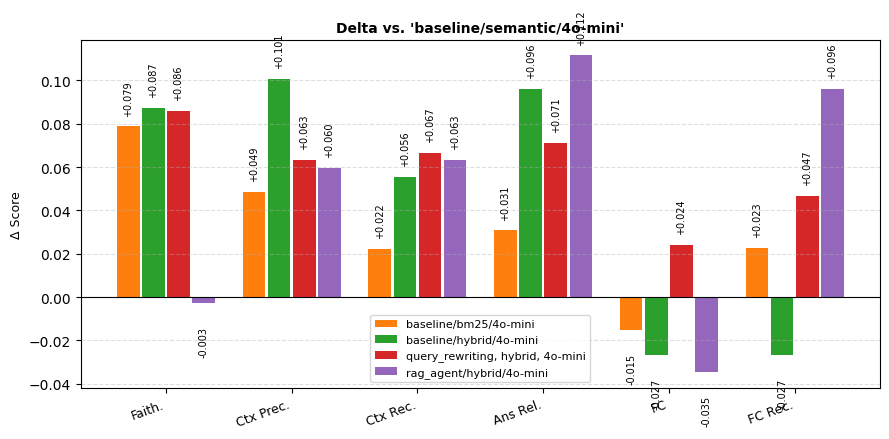

In [44]:
if len(run_data) >= 2:
    metrics = metrics_present_in(overall)
    short   = [METRIC_SHORT.get(m, m) for m in metrics]
    n_runs  = len(delta_others)
    x       = np.arange(len(metrics))
    width   = 0.8 / n_runs

    fig, ax = plt.subplots(figsize=(max(8, len(metrics) * 1.5), 4.5))
    for i, label in enumerate(delta_others.index):
        vals   = delta_others.loc[label, metrics].values.astype(float)
        offset = (i - (n_runs - 1) / 2) * width
        bars   = ax.bar(x + offset, vals, width * 0.9,
                        label=label, color=COLORS[(i + 1) % len(COLORS)])
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    v + (0.005 if v >= 0 else -0.025),
                    f"{v:+.3f}", ha="center", va="bottom", fontsize=7, rotation=90
                )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(short, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Δ Score", fontsize=9)
    ax.set_title(f"Delta vs. '{baseline_label}'", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

---
## 6. Per-question-class delta vs. first run

In [45]:
if len(run_data) >= 2:
    baseline_label = LABELS[0]
    baseline_qclass = by_qclass.xs(baseline_label, axis=1, level="run")
    for label in LABELS[1:]:
        other   = by_qclass.xs(label, axis=1, level="run")
        delta_q = other - baseline_qclass
        print(f"Delta by question_class: '{label}' − '{baseline_label}'")
        display(delta_q)

Delta by question_class: 'baseline/bm25/4o-mini' − 'baseline/semantic/4o-mini'


metric,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
question_class,,,,,,
fact_single,-0.0700,-0.1400,0.0000,-0.1738,-0.0460,0.0000
reasoning,-0.0954,0.0372,0.0000,-0.0239,-0.1800,-0.1220
summary,0.4017,0.2483,0.0667,0.2899,0.1800,0.1900
unanswerable,-0.0571,0.0667,0.2000,0.1821,-0.0800,-0.2000


Delta by question_class: 'baseline/hybrid/4o-mini' − 'baseline/semantic/4o-mini'


metric,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
question_class,,,,,,
fact_single,-0.0700,0.0265,0.0000,-0.1204,-0.2440,-0.3000
reasoning,0.0218,0.1064,0.1000,0.0227,0.0080,0.0220
summary,0.3118,0.1690,0.0667,0.3857,0.1560,0.1980
unanswerable,0.1429,0.0000,0.0000,0.0000,0.0920,0.0000


Delta by question_class: 'query_rewriting, hybrid, 4o-mini' − 'baseline/semantic/4o-mini'


metric,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
question_class,,,,,,
fact_single,0.0633,0.0283,0.0000,-0.1226,-0.0460,-0.1340
reasoning,-0.0671,0.0781,0.1000,0.0026,-0.0500,0.0700
summary,0.2617,0.0831,0.1000,0.3340,0.1680,0.2040
unanswerable,-0.1071,0.0000,0.0000,0.0000,0.0920,0.0000


Delta by question_class: 'rag_agent/hybrid/4o-mini' − 'baseline/semantic/4o-mini'


metric,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
question_class,,,,,,
fact_single,0.0300,-0.0319,0.2000,0.0165,-0.0980,-0.1000
reasoning,-0.1774,0.1286,0.0000,-0.0155,-0.1380,0.1100
summary,0.1185,0.0974,-0.0333,0.3336,0.1320,0.2780
unanswerable,-0.3468,0.0000,0.2000,0.3820,-0.2800,-0.4000


---
## 7. Raw rows (for custom analysis)

In [46]:
all_rows = pd.concat(run_data.values(), ignore_index=True)
print(f"Total rows: {len(all_rows)}")
cols = ["run_label", "run_id", "user_input", "question_class", "subdomain"] + \
       [c for c in METRIC_COLS if c in all_rows.columns]
all_rows[cols].head(10)

Total rows: 100


,run_label,run_id,user_input,question_class,subdomain,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
0,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,How many qubits are typically found in a NISQ-...,fact_single,nisq_constraints_and_qsd_constraints,1.0000,0.5889,1.0000,0.9536,1.0000,1.0000
1,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,What are the primary challenges quantum resear...,summary,nisq_constraints_and_qsd_constraints,0.6471,0.7222,0.6667,0.9508,0.4300,0.5000
2,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,Why does the accuracy of my results typically ...,reasoning,nisq_constraints_and_qsd_constraints,0.8000,0.9667,1.0000,0.9777,0.7700,0.7100
3,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,What is the specific hourly cost for accessing...,unanswerable,nisq_constraints_and_qsd_constraints,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000
4,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,What is the fundamental unit of organization f...,fact_single,experiment_tracking_fundamentals,1.0000,0.5667,1.0000,1.0000,0.4000,0.5000
5,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,What does the experiment tracking process actu...,summary,experiment_tracking_fundamentals,1.0000,0.9167,0.6667,0.9125,0.2900,0.5000
6,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,If my quantum algorithm's source code hasn't c...,reasoning,experiment_tracking_fundamentals,0.5625,0.9667,0.5000,0.9364,0.6200,0.7500
7,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,What is the maximum storage capacity in gigaby...,unanswerable,experiment_tracking_fundamentals,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000
8,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,Does the QProv definition of circuit width inc...,fact_single,qprov_provenance_taxonomy,1.0000,0.8100,1.0000,0.8885,1.0000,1.0000
9,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,Can you give me an overview of the four main c...,summary,qprov_provenance_taxonomy,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
